# Look at one SpectralWaste image

A hyperspectral pixel is a whole spectrum, not just red, green, and blue.
This notebook opens one training sample so you can see the cube, the label mask, and the class names.

Run the cells from top to bottom. You need the dataset on disk first (`scripts/get_data.sh`).


## Colab setup

Skip this cell on your own machine. In Colab it clones the repo, installs the libraries, and downloads the data (about 23 GB).


In [1]:
import os
import subprocess
import sys
from pathlib import Path

# This cell is only for Google Colab. On your own machine it does nothing.
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.chdir("/content")
    repo = Path("/content/255-final-project")
    if not repo.is_dir():
        subprocess.check_call(
            ["git", "clone", "https://github.com/scottn66/255-final-project.git", str(repo)]
        )
    os.chdir(repo)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"]
    )
    if not os.environ.get("SW_ROOT"):
        subprocess.check_call(["bash", "scripts/get_data.sh", "/content/data"])
        os.environ["SW_ROOT"] = "/content/data/spectralwaste_segmentation"


## Find the data

The loader reads the `SW_ROOT` environment variable. That folder is the unpacked `spectralwaste_segmentation` directory (it contains `hyper/` and `labels_hyper_lt/`).


In [2]:
import os

if not os.environ.get("SW_ROOT"):
    raise RuntimeError(
        "SW_ROOT is not set, so this notebook cannot find the dataset.\n\n"
        "From the repo root, download it (about 23 GB) and export the path "
        "the script prints:\n\n"
        "    bash scripts/get_data.sh\n"
        "    export SW_ROOT=\"/absolute/path/printed/by/the/script\"\n\n"
        "That folder contains hyper/ and labels_hyper_lt/.\n"
        "Restart the kernel, then run this notebook from the top."
    )
print("SW_ROOT =", os.environ["SW_ROOT"])


SW_ROOT = ./data/spectralwaste_segmentation


## Load one training sample

Each cube is stored as uint16, band-first. The loader divides by 65535, so the values you get are float32 in `[0, 1]`.
The mask is a PNG of class ids. The cube `<stem>.tiff` and the mask `<stem>.png` share the same stem.
Real cubes are `(224, 256, 256)`.


In [3]:
import sys
from pathlib import Path


def _add_src():
    here = Path.cwd().resolve()
    for cand in [here, *here.parents]:
        src = cand / "src"
        if (src / "sw" / "__init__.py").is_file():
            if str(src) not in sys.path:
                sys.path.insert(0, str(src))
            return
    raise RuntimeError(
        "Could not import sw. Start Jupyter from the repo root or from the notebooks/ folder."
    )


_add_src()

import matplotlib.pyplot as plt
import numpy as np
import torch

from sw import CLASS_NAMES, HYPER_LT_TRAIN_PIXEL_COUNTS, PALETTE, SpectralWasteDataset

train = SpectralWasteDataset(split="train")
cube, mask = train[0]
print("train images:", len(train))
print("cube:", tuple(cube.shape), cube.dtype, "min", float(cube.min()), "max", float(cube.max()))
print("mask:", tuple(mask.shape), mask.dtype, "class ids", torch.unique(mask).tolist())


train images: 514
cube: (224, 256, 256) torch.float32 min 0.10417333990335464 max 0.999969482421875
mask: (256, 256) torch.int64 class ids [0, 1, 6]


## False colour

Three bands, drawn as red, green, and blue, are enough to see the scene.
The cube has many more bands than these three. Each band is stretched for display, so the colours are only a picture, not the raw values.


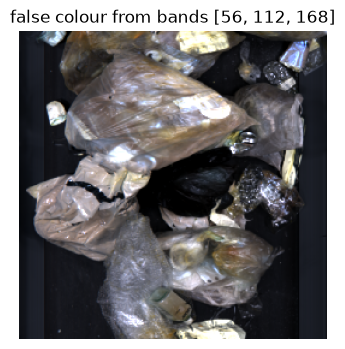

In [4]:
channels, _height, _width = cube.shape
band_ids = [channels // 4, channels // 2, (3 * channels) // 4]
rgb = cube[band_ids].numpy().transpose(1, 2, 0).copy()
for k in range(3):
    low, high = np.percentile(rgb[..., k], [2, 98])
    rgb[..., k] = np.clip((rgb[..., k] - low) / (high - low + 1e-6), 0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(rgb)
plt.title(f"false colour from bands {band_ids}")
plt.axis("off")
plt.show()


## Label mask

Class ids are `0` background, `1` film, `2` basket, `3` cardboard, `4` video_tape, `5` filament, `6` bag.
The colours are the palette from the dataset `meta.json`.
The labels don't cover every object, so some visible objects count as background.


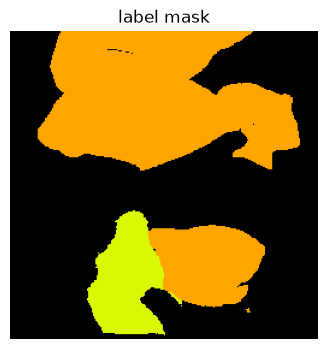

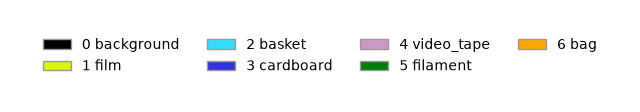

In [5]:
from matplotlib.patches import Patch

mask_np = mask.numpy()
color = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
for class_id, rgb_u8 in enumerate(PALETTE):
    color[mask_np == class_id] = rgb_u8

plt.figure(figsize=(4, 4))
plt.imshow(color)
plt.title("label mask")
plt.axis("off")
plt.show()

handles = [
    Patch(facecolor=np.array(rgb_u8) / 255, edgecolor="0.6", label=f"{i} {name}")
    for i, (name, rgb_u8) in enumerate(zip(CLASS_NAMES, PALETTE))
]
plt.figure(figsize=(8, 1.2))
plt.legend(handles=handles, ncol=4, loc="center", frameon=False)
plt.axis("off")
plt.show()


## Mean spectrum of each class

For every class that appears in this image, average the cube over those pixels.
The x-axis is the band index. `meta.json` ships no wavelengths; the paper reports 224 bands over roughly 900–1700 nm.
This is one image, so read the curves as a sketch of the data.


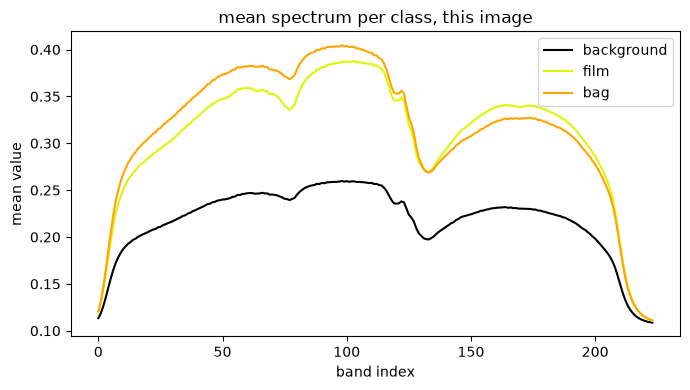

In [6]:
plt.figure(figsize=(7, 4))
for class_id, name in enumerate(CLASS_NAMES):
    chosen = mask_np == class_id
    if not chosen.any():
        continue
    spectrum = cube[:, chosen].mean(dim=1).numpy()
    plt.plot(np.arange(channels), spectrum, label=name, color=np.array(PALETTE[class_id]) / 255)
plt.xlabel("band index")
plt.ylabel("mean value")
plt.title("mean spectrum per class, this image")
plt.legend()
plt.tight_layout()
plt.show()


## Class pixel counts

The bar chart is this image only.

Under it are the **train-split** counts for `labels_hyper_lt`, the hyperspectral masks.
`meta.json` also has a `categories_pixel_counts` field. Those numbers are the RGB-label counts, and they are different. Use the hyperspectral counts when you weight a loss on these masks.


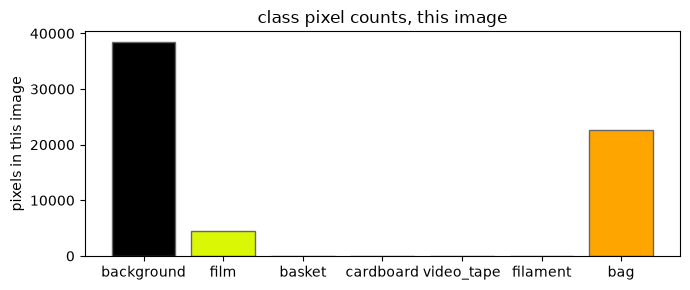

labels_hyper_lt train pixel counts (whole train split):
  background     27612233
  film            1819248
  basket          1060150
  cardboard        220623
  video_tape       397471
  filament          33101
  bag             2542678


In [7]:
counts = np.bincount(mask_np.ravel(), minlength=len(CLASS_NAMES))
plt.figure(figsize=(7, 3))
plt.bar(CLASS_NAMES, counts, color=np.array(PALETTE) / 255, edgecolor="0.4")
plt.ylabel("pixels in this image")
plt.title("class pixel counts, this image")
plt.tight_layout()
plt.show()

print("labels_hyper_lt train pixel counts (whole train split):")
for name, n in zip(CLASS_NAMES, HYPER_LT_TRAIN_PIXEL_COUNTS):
    print(f"  {name:12} {n:10d}")
